In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Step 1 Import Libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Step 2 Load dataset
df= pd.read_csv("customer_data.csv")

In [4]:
df.head()

,customer_id,monthly_spend,visit_frequency,avg_order_value,loyalty_member
0,1,45.5,8,5.69,0
1,2,32.2,5,6.44,0
2,3,67.8,15,4.52,1
3,4,28.9,4,7.23,0
4,5,89.3,22,4.06,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      50 non-null     int64  
 1   monthly_spend    50 non-null     float64
 2   visit_frequency  50 non-null     int64  
 3   avg_order_value  50 non-null     float64
 4   loyalty_member   50 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.1 KB


In [6]:
df.describe()

,customer_id,monthly_spend,visit_frequency,avg_order_value,loyalty_member
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,56.060000,12.640000,5.091000,0.480000
std,14.57738,24.294948,7.433405,1.368564,0.504672
min,1.00000,12.500000,2.000000,3.630000,0.000000
25%,13.25000,36.225000,6.250000,4.155000,0.000000
50%,25.50000,54.400000,12.000000,4.585000,0.000000
75%,37.75000,71.875000,17.750000,5.660000,1.000000
max,50.00000,102.400000,28.000000,9.900000,1.000000


In [7]:
df.isnull().sum()

customer_id        0
monthly_spend      0
visit_frequency    0
avg_order_value    0
loyalty_member     0
dtype: int64

In [8]:
# Step 3 Preparing data
X = df[['monthly_spend', 'visit_frequency']]
X.head()

,monthly_spend,visit_frequency
0,45.5,8
1,32.2,5
2,67.8,15
3,28.9,4
4,89.3,22


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled_df = pd.DataFrame(X_scaled, columns= ['monthly_spend', 'visit_frequency'])

In [11]:
X_scaled_df.head(5)

,monthly_spend,visit_frequency
0,-0.439071,-0.630547
1,-0.992068,-1.038227
2,0.488134,0.320709
3,-1.129278,-1.174121
4,1.382076,1.271965


In [12]:
X_scaled_df.describe()

,monthly_spend,visit_frequency
count,5.000000e+01,5.000000e+01
mean,-6.661338e-17,-5.329071e-17
std,1.010153e+00,1.010153e+00
min,-1.811169e+00,-1.445908e+00
25%,-8.247137e-01,-8.683604e-01
50%,-6.902066e-02,-8.697194e-02
75%,6.575673e-01,6.944166e-01
max,1.926757e+00,2.087326e+00


Testing different k values
 k=2: wcss = 27.41
 k=3: wcss = 11.30
 k=4: wcss = 5.93
 k=5: wcss = 4.30
 k=6: wcss = 3.13
 k=7: wcss = 2.27
 k=8: wcss = 1.74
 k=9: wcss = 1.42
 k=10: wcss = 1.15
Elbow calculated


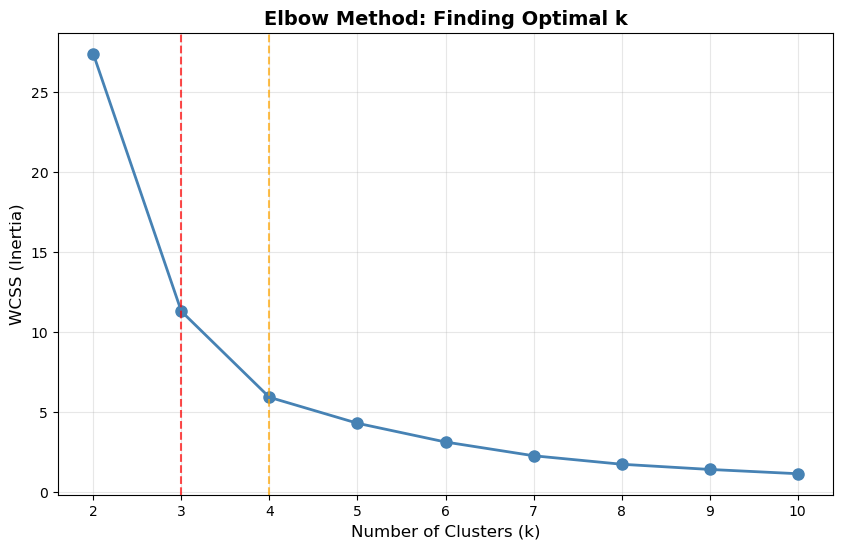

In [13]:
# Step 4 ELBOW Method
# wcss for different k values
wcss = []
k_range = range(2,11)
print("Testing different k values")
for k in k_range:
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(f" k={k}: wcss = {kmeans.inertia_:.2f}")

print("Elbow calculated")
# Plot
plt.figure(figsize=(10,6))
plt.plot(k_range, wcss, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.title('Elbow Method: Finding Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Mark the elbow (usually around k=3 or k=4)
plt.axvline(x=3, color='red', linestyle='--', label='Potential Elbow', alpha=0.7)
plt.axvline(x=4, color='orange', linestyle='--', label='Potential Elbow', alpha=0.7)



In [14]:
silhouette_scores_list = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_scaled)
    
    # Call the function
    score = silhouette_score(X_scaled, labels)
    
    # Append to list
    silhouette_scores_list.append(score)
    print(f"   k={k}: Silhouette Score = {score:.4f}")

   k=2: Silhouette Score = 0.5946
   k=3: Silhouette Score = 0.5878
   k=4: Silhouette Score = 0.5744
   k=5: Silhouette Score = 0.5325
   k=6: Silhouette Score = 0.5161
   k=7: Silhouette Score = 0.4953
   k=8: Silhouette Score = 0.4788
   k=9: Silhouette Score = 0.4688
   k=10: Silhouette Score = 0.4631


\ BEST k by Silhouette: k=2 (score=0.5946)


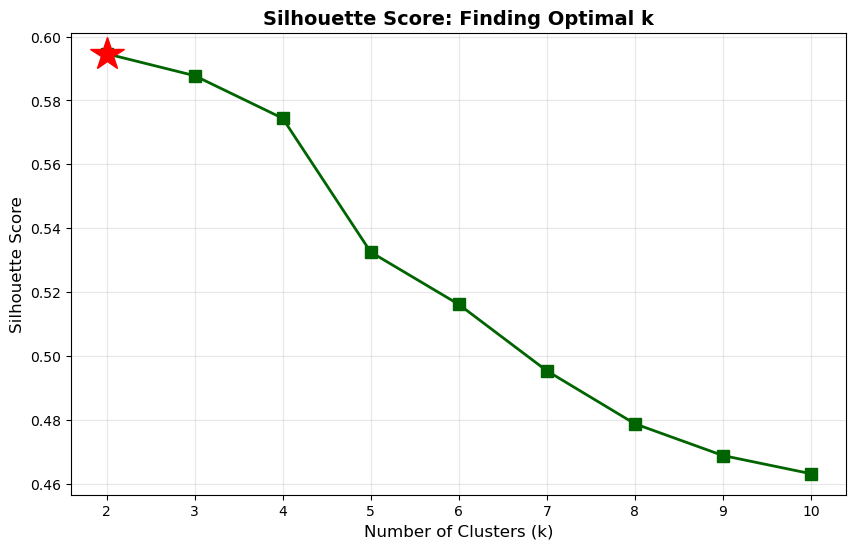

In [15]:
# Find best k
best_k = k_range[silhouette_scores_list.index(max(silhouette_scores_list))]
best_score = max(silhouette_scores_list)
print(f"\ BEST k by Silhouette: k={best_k} (score={best_score:.4f})")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores_list, marker='s', linewidth=2, markersize=8, color='darkgreen')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score: Finding Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.plot(best_k, best_score, marker='*', markersize=25, color='red', label=f'Best: k={best_k}')

In [16]:
# Step 5. FINAL CLUSTERING
print(f" Step 5: Final clustering with k={best_k}...")
optimal_k = best_k

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df['cluster'] = cluster_labels

print(f" Clustering complete!")
print("\n Cluster distribution:")
print(df['cluster'].value_counts().sort_index())

final_silhouette_score = silhouette_score(X_scaled, cluster_labels)
print(f"\n Final Silhouette Score: {final_silhouette_score:.4f}")

 Step 5: Final clustering with k=2...
 Clustering complete!

 Cluster distribution:
cluster
0    22
1    28
Name: count, dtype: int64

 Final Silhouette Score: 0.5946


 Step 6: Creating visualization...


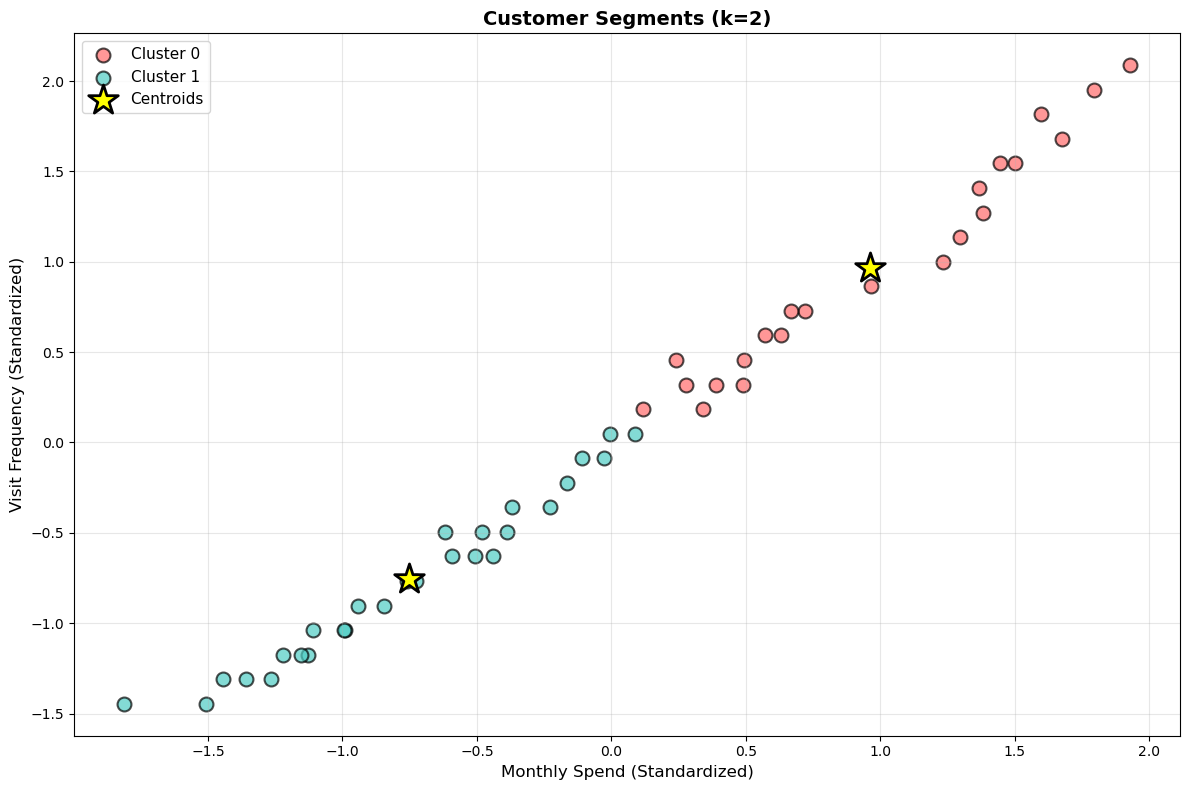

In [17]:
# Step 6. VISUALIZATION 
print(" Step 6: Creating visualization...")
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F38181'][:optimal_k]

for i in range(optimal_k):
    cluster_points = X_scaled[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=colors[i], label=f'Cluster {i}', s=100, alpha=0.7, 
               edgecolors='black', linewidth=1.5)

plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
           c='yellow', marker='*', s=500, edgecolors='black', linewidth=2,
           label='Centroids', zorder=5)

plt.xlabel('Monthly Spend (Standardized)', fontsize=12)
plt.ylabel('Visit Frequency (Standardized)', fontsize=12)
plt.title(f'Customer Segments (k={optimal_k})', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Step 7. CLUSTER ANALYSIS 

print("CLUSTER ANALYSIS - BUSINESS INSIGHTS")


for cluster_num in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_num]
    
    print(f"\n🎯 CLUSTER {cluster_num}")
    print("-" * 80)
    print(f"   Size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"\n   💰 Monthly Spend:")
    print(f"      Average: ${cluster_data['monthly_spend'].mean():.2f}")
    print(f"      Range: ${cluster_data['monthly_spend'].min():.2f} - ${cluster_data['monthly_spend'].max():.2f}")
    
    print(f"\n   📍 Visit Frequency:")
    print(f"      Average: {cluster_data['visit_frequency'].mean():.1f} visits/month")
    print(f"      Range: {cluster_data['visit_frequency'].min()} - {cluster_data['visit_frequency'].max()} visits")
    
    print(f"\n   🛍️ Avg Order Value:")
    print(f"      ${cluster_data['avg_order_value'].mean():.2f}")
    
    loyalty_pct = cluster_data['loyalty_member'].mean() * 100
    print(f"\n   🎟️ Loyalty Members: {loyalty_pct:.1f}%")


CLUSTER ANALYSIS - BUSINESS INSIGHTS

🎯 CLUSTER 0
--------------------------------------------------------------------------------
   Size: 22 customers (44.0%)

   💰 Monthly Spend:
      Average: $79.13
      Range: $58.90 - $102.40

   📍 Visit Frequency:
      Average: 19.7 visits/month
      Range: 14 - 28 visits

   🛍️ Avg Order Value:
      $4.06

   🎟️ Loyalty Members: 100.0%

🎯 CLUSTER 1
--------------------------------------------------------------------------------
   Size: 28 customers (56.0%)

   💰 Monthly Spend:
      Average: $37.93
      Range: $12.50 - $58.20

   📍 Visit Frequency:
      Average: 7.1 visits/month
      Range: 2 - 13 visits

   🛍️ Avg Order Value:
      $5.90

   🎟️ Loyalty Members: 7.1%


In [20]:
# Step 8. NAME CLUSTERS =====
print("\n" + "="*80)
print("CLUSTER NAMES & BUSINESS STRATEGY")
print("="*80)

cluster_names = {
    0: "Budget-Conscious Occasional Buyers",
    1: "Premium Loyal Regulars",
    2: "Moderate Frequency Customers"
}

# Adjust for different k values
if optimal_k == 2:
    cluster_names = {
        0: "Budget Buyers",
        1: "Premium Regulars"
    }
elif optimal_k == 4:
    cluster_names = {
        0: "Very Low Spenders",
        1: "Budget Conscious",
        2: "Moderate Customers",
        3: "Premium Regulars"
    }

df['cluster_name'] = df['cluster'].map(cluster_names)

for cluster_num in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_num]
    name = cluster_names.get(cluster_num, f"Cluster {cluster_num}")
    avg_spend = cluster_data['monthly_spend'].mean()
    count = len(cluster_data)
    
    print(f"\n📌 Cluster {cluster_num}: {name}")
    print(f"   → {count} customers ({count/len(df)*100:.1f}%)")
    print(f"   → Average monthly spend: ${avg_spend:.2f}")


CLUSTER NAMES & BUSINESS STRATEGY

📌 Cluster 0: Budget Buyers
   → 22 customers (44.0%)
   → Average monthly spend: $79.13

📌 Cluster 1: Premium Regulars
   → 28 customers (56.0%)
   → Average monthly spend: $37.93


In [21]:
# Step 9. MARKETING STRATEGY =====
print("\n" + "="*80)
print("RECOMMENDED MARKETING STRATEGIES")
print("="*80)

strategies = {
    0: {
        'name': 'Budget-Conscious Occasional Buyers',
        'strategy': '20% off coupons, Happy Hour promotions, Entry-level combos',
        'action': 'Send weekly discount emails'
    },
    1: {
        'name': 'Premium Loyal Regulars',
        'strategy': 'VIP perks, Exclusive drinks, Personal recommendations',
        'action': 'Free premium drink monthly, Priority ordering'
    },
    2: {
        'name': 'Moderate Frequency Customers',
        'strategy': 'Loyalty rewards, Limited-time offers, Engagement programs',
        'action': 'Bonus points campaigns, Seasonal specials'
    }
}

for cluster_num in range(min(optimal_k, 3)):
    if cluster_num in strategies:
        info = strategies[cluster_num]
        print(f"\n🎯 {info['name'].upper()}")
        print(f"   Strategy: {info['strategy']}")
        print(f"   Action: {info['action']}")


RECOMMENDED MARKETING STRATEGIES

🎯 BUDGET-CONSCIOUS OCCASIONAL BUYERS
   Strategy: 20% off coupons, Happy Hour promotions, Entry-level combos
   Action: Send weekly discount emails

🎯 PREMIUM LOYAL REGULARS
   Strategy: VIP perks, Exclusive drinks, Personal recommendations
   Action: Free premium drink monthly, Priority ordering


In [22]:
# Step 10. SAVE RESULTS =====
df.to_csv('clustered_customers.csv', index=False)

print("\n" + "="*80)
print("✅ Results saved to 'clustered_customers.csv'")
print("🎉 PROJECT COMPLETE!")
print("="*80)


✅ Results saved to 'clustered_customers.csv'
🎉 PROJECT COMPLETE!
